# Roteamento Urbano de Emergência em Belém do Pará

## 1. Identificação e Declaração
- **Nomes dos integrantes:** Davi Costa, Rafael Diniz, Ramon Souza e Thiago Pamplona
- **Declaração de uso de IA Generativa:** Ferramenta utilizada: Antigravity / Gemini 3.1 Pro (High). Finalidade: Implementação de base dos algoritmos e estruturação do notebook. Extensão: A IA gerou a infraestrutura de código e implementou a lógica base dos algoritmos de busca (Busca Gulosa, A*, Weighted A* e A* Bidirecional). A equipe coordenou as diretrizes, definiu a modelagem do problema, revisou a corretude e elaborou a análise crítica. Medidas de validação: Verificação visual das rotas e das árvores de busca, comparação dos custos e debug empírico dos nós expandidos.
- **Instruções de reprodução:** Para reproduzir este experimento, instale as dependências executando: `pip install osmnx networkx matplotlib folium scipy pandas`


## 2. Contextualização e Modelagem do Problema

Neste trabalho, modelamos o problema do despacho de veículos de emergência (ambulâncias) saindo do Hospital Unimed Prime até pontos de ocorrência. Para que os algoritmos de Inteligência Artificial possam resolver o problema, precisamos traduzir a cidade para o mundo matemático.

### Como o problema foi modelado (O nosso "Raciocínio")
Para aplicar a Busca Heurística, definimos a estrutura do nosso ambiente:
1. **Espaço de Estados (O Grafo):** Extraímos a malha viária real usando OpenStreetMap (OSMnx). Cada Nó da nossa árvore representa um cruzamento/esquina da cidade. Cada Aresta representa o trecho de rua entre dois cruzamentos.
2. **Função de Custo ( g(n) ):** O esforço (custo) de se mover de um nó a outro foi definido como a distância física real (em metros) daquele trecho de rua. (Em uma melhoria futura, poderia ser o tempo estimado considerando o trânsito).
3. **Função Heurística ( h(n) ):** Para guiar o algoritmo, usamos a fórmula de Haversine. Ela calcula a distância geográfica "em linha reta" (voo de pássaro) entre o cruzamento atual onde a busca está e o destino final (a ocorrência).
4. **Admissibilidade:** Como é impossível um carro percorrer as ruas retorcidas da cidade em uma distância menor do que um voo reto, nossa heurística nunca superestima o custo real. Logo, ela é admissível, o que garante matematicamente que o A* puro sempre vai encontrar a rota perfeita (ótima).

**O Trade-off:** 
Em rotas curtas, a diferença entre os algoritmos não é gritante. Mas quando a ambulância precisa ir para muito longe (como Icoaraci), algoritmos ótimos como o A* clássico "explodem" em memória, pois tentam abrir nós da cidade inteira. Algoritmos sub-ótimos (como a Busca Gulosa ou o Weighted A*) sacrificam a garantia de encontrar o caminho perfeito para chegar a uma solução muito mais rápido, rasgando o mapa na direção da heurística.


## 3. Setup do Ambiente e Extração do Grafo
Abaixo inicializamos as ferramentas e baixamos a cidade.

In [2]:
import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt
import folium
import heapq
import time
import math
import pandas as pd

ox.settings.log_console = True
ox.settings.use_cache = True


In [3]:
G = ox.graph_from_place('Belém, Pará, Brazil', network_type='drive')

G = ox.add_edge_speeds(G)
G = ox.add_edge_travel_times(G)
print(f"Grafo baixado com sucesso: {len(G.nodes)} nós e {len(G.edges)} arestas.")


Grafo baixado com sucesso: 15080 nós e 37537 arestas.


In [4]:
# Coordenadas aproximadas (lat, lon) de destinos em diferentes escalas de distância
loc_hospital = (-1.454238, -48.468761) # Hospital Unimed Prime (Guamá)

loc_dest_curto = (-1.474665, -48.455432) # UFPA (Destino Curto)
loc_dest_medio = (-1.384784, -48.477218) # Aeroporto Internacional de Belém (Destino Médio)
loc_dest_longo = (-1.298106, -48.487042) # Orla de Icoaraci (Destino Longo)

# Encontrar os nós mais próximos no grafo
orig_node = ox.distance.nearest_nodes(G, X=loc_hospital[1], Y=loc_hospital[0])
dest_node1 = ox.distance.nearest_nodes(G, X=loc_dest_curto[1], Y=loc_dest_curto[0])
dest_node2 = ox.distance.nearest_nodes(G, X=loc_dest_medio[1], Y=loc_dest_medio[0])
dest_node3 = ox.distance.nearest_nodes(G, X=loc_dest_longo[1], Y=loc_dest_longo[0])

destinations = {
    "UFPA (Curto)": dest_node1,
    "Aeroporto (Médio)": dest_node2,
    "Orla de Icoaraci (Longo)": dest_node3
}

print(f"Nó Origem (Hospital): {orig_node}")
for nome, no in destinations.items():
    print(f"Destino - {nome}: {no}")


Nó Origem (Hospital): 6950883265
Destino - UFPA (Curto): 6951751894
Destino - Aeroporto (Médio): 495406456
Destino - Orla de Icoaraci (Longo): 490949714


## 4. Implementação dos Algoritmos de Busca
Os algoritmos foram modificados para retornar um **Conjunto (Set) de Nós Explorados**. Isso nos permitirá desenhar visualmente a "Árvore de Busca" gerada por cada um.

In [5]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371000  # Raio da Terra em metros
    phi1, phi2 = math.radians(lat1), math.radians(lat2)
    delta_phi = math.radians(lat2 - lat1)
    delta_lambda = math.radians(lon2 - lon1)
    
    a = math.sin(delta_phi/2.0)**2 + math.cos(phi1) * math.cos(phi2) * math.sin(delta_lambda/2.0)**2
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1-a))
    return R * c

def heuristic(G, node1, node2):
    lat1, lon1 = G.nodes[node1]['y'], G.nodes[node1]['x']
    lat2, lon2 = G.nodes[node2]['y'], G.nodes[node2]['x']
    return haversine(lat1, lon1, lat2, lon2)

def get_edge_weight(G, u, v, weight_type='length'):
    return min(G.get_edge_data(u, v).values(), key=lambda d: d.get(weight_type, float('inf'))).get(weight_type, 1)


In [6]:
def greedy_bfs(G, start, goal):
    start_time = time.time()
    frontier = []
    heapq.heappush(frontier, (0, start))
    came_from = {start: None}
    expanded_nodes = set()
    
    while frontier:
        _, current = heapq.heappop(frontier)
        expanded_nodes.add(current)
        
        if current == goal:
            break
            
        for neighbor in G.neighbors(current):
            if neighbor not in came_from:
                priority = heuristic(G, neighbor, goal)
                heapq.heappush(frontier, (priority, neighbor))
                came_from[neighbor] = current
                
    path = []
    curr = goal
    cost = 0
    if curr in came_from:
        while curr is not None:
            path.append(curr)
            nxt = came_from[curr]
            if nxt is not None:
                cost += get_edge_weight(G, nxt, curr)
            curr = nxt
        path.reverse()
        
    return path, cost, expanded_nodes, time.time() - start_time


In [7]:
def a_star_search(G, start, goal, weight=1.0):
    start_time = time.time()
    frontier = []
    heapq.heappush(frontier, (0, start))
    came_from = {start: None}
    cost_so_far = {start: 0}
    expanded_nodes = set()
    
    while frontier:
        _, current = heapq.heappop(frontier)
        expanded_nodes.add(current)
        
        if current == goal:
            break
            
        for neighbor in G.neighbors(current):
            new_cost = cost_so_far[current] + get_edge_weight(G, current, neighbor)
            
            if neighbor not in cost_so_far or new_cost < cost_so_far[neighbor]:
                cost_so_far[neighbor] = new_cost
                priority = new_cost + weight * heuristic(G, neighbor, goal)
                heapq.heappush(frontier, (priority, neighbor))
                came_from[neighbor] = current
                
    path = []
    curr = goal
    if curr in came_from:
        while curr is not None:
            path.append(curr)
            curr = came_from[curr]
        path.reverse()
        
    return path, cost_so_far.get(goal, float('inf')), expanded_nodes, time.time() - start_time


## 5. Execução dos Algoritmos
Vamos rodar para todos os destinos e armazenar os conjuntos de nós expandidos para visualizar mais tarde.

In [8]:
results = []
paths_dict = {}
explored_dict = {} 

algoritmos = {
    "Gulosa": lambda s, g: greedy_bfs(G, s, g),
    "A* (w=1.0)": lambda s, g: a_star_search(G, s, g, weight=1.0),
    "Weighted A* (w=1.5)": lambda s, g: a_star_search(G, s, g, weight=1.5),
    "Weighted A* (w=2.0)": lambda s, g: a_star_search(G, s, g, weight=2.0),
}

for dest_name, dest_node in destinations.items():
    paths_dict[dest_name] = {}
    explored_dict[dest_name] = {}
    print(f"\nCalculando rotas para: {dest_name}")

    for alg_name, alg_func in algoritmos.items():
        path, cost, exp_nodes_set, exec_time = alg_func(orig_node, dest_node)

        paths_dict[dest_name][alg_name] = path
        explored_dict[dest_name][alg_name] = exp_nodes_set

        results.append({
            "Destino": dest_name,
            "Algoritmo": alg_name,
            "Custo (m)": round(cost, 2),
            "Nós Expandidos": len(exp_nodes_set),
            "Tempo (s)": round(exec_time, 5)
        })
        print(f"[{alg_name}] Concluído. Nós: {len(exp_nodes_set)} | Custo: {round(cost, 2)}m")


Calculando rotas para: UFPA (Curto)
[Gulosa] Concluído. Nós: 59 | Custo: 4085.31m
[A* (w=1.0)] Concluído. Nós: 396 | Custo: 3410.81m
[Weighted A* (w=1.5)] Concluído. Nós: 77 | Custo: 3621.58m
[Weighted A* (w=2.0)] Concluído. Nós: 45 | Custo: 3513.4m

Calculando rotas para: Aeroporto (Médio)
[Gulosa] Concluído. Nós: 393 | Custo: 19848.01m
[A* (w=1.0)] Concluído. Nós: 5103 | Custo: 11754.9m
[Weighted A* (w=1.5)] Concluído. Nós: 1566 | Custo: 12009.9m
[Weighted A* (w=2.0)] Concluído. Nós: 375 | Custo: 12347.95m

Calculando rotas para: Orla de Icoaraci (Longo)
[Gulosa] Concluído. Nós: 442 | Custo: 25124.81m
[A* (w=1.0)] Concluído. Nós: 6586 | Custo: 20717.08m
[Weighted A* (w=1.5)] Concluído. Nós: 787 | Custo: 21044.77m
[Weighted A* (w=2.0)] Concluído. Nós: 403 | Custo: 22247.93m


## 6. Evidências Visuais (Mapa Interativo da Rota)
Renderização da rota da ambulância no mapa real usando Folium.

In [9]:
alvo = "Orla de Icoaraci (Longo)"
rota_a_star = paths_dict[alvo]["A* (w=1.0)"]

if rota_a_star:
    route_coords = [(G.nodes[node]['y'], G.nodes[node]['x']) for node in rota_a_star]
    meio = len(route_coords) // 2
    route_map = folium.Map(location=route_coords[meio], zoom_start=12)
    
    folium.PolyLine(route_coords, color="#ff0000", weight=5, opacity=0.8).add_to(route_map)
    folium.Marker(location=[loc_hospital[0], loc_hospital[1]], popup="Hospital Unimed (Origem)", 
                  icon=folium.Icon(color="blue", icon="plus")).add_to(route_map)
    folium.Marker(location=[G.nodes[destinations[alvo]]['y'], G.nodes[destinations[alvo]]['x']], 
                  popup=f"{alvo}", icon=folium.Icon(color="green")).add_to(route_map)
    display(route_map)
else:
    print("Nenhuma rota encontrada.")


## 7. VISUALIZAÇÃO DA ÁRVORE DE BUSCA (A Mágica da Heurística)
Esta é a visualização gráfica para entendermos exatamente **o que o algoritmo pensou e por onde ele procurou** antes de achar o destino.
- **Pontos Vermelhos:** Representam todos os cruzamentos que a IA "visitou" na tentativa de achar Icoaraci.
- **Linha Azul:** Representa a rota final selecionada.

Note a diferença monstruosa entre o A* puro (que abre uma "bola" enorme na cidade toda) e o Weighted A* (que confia na heurística e atira direto na direção de Icoaraci).

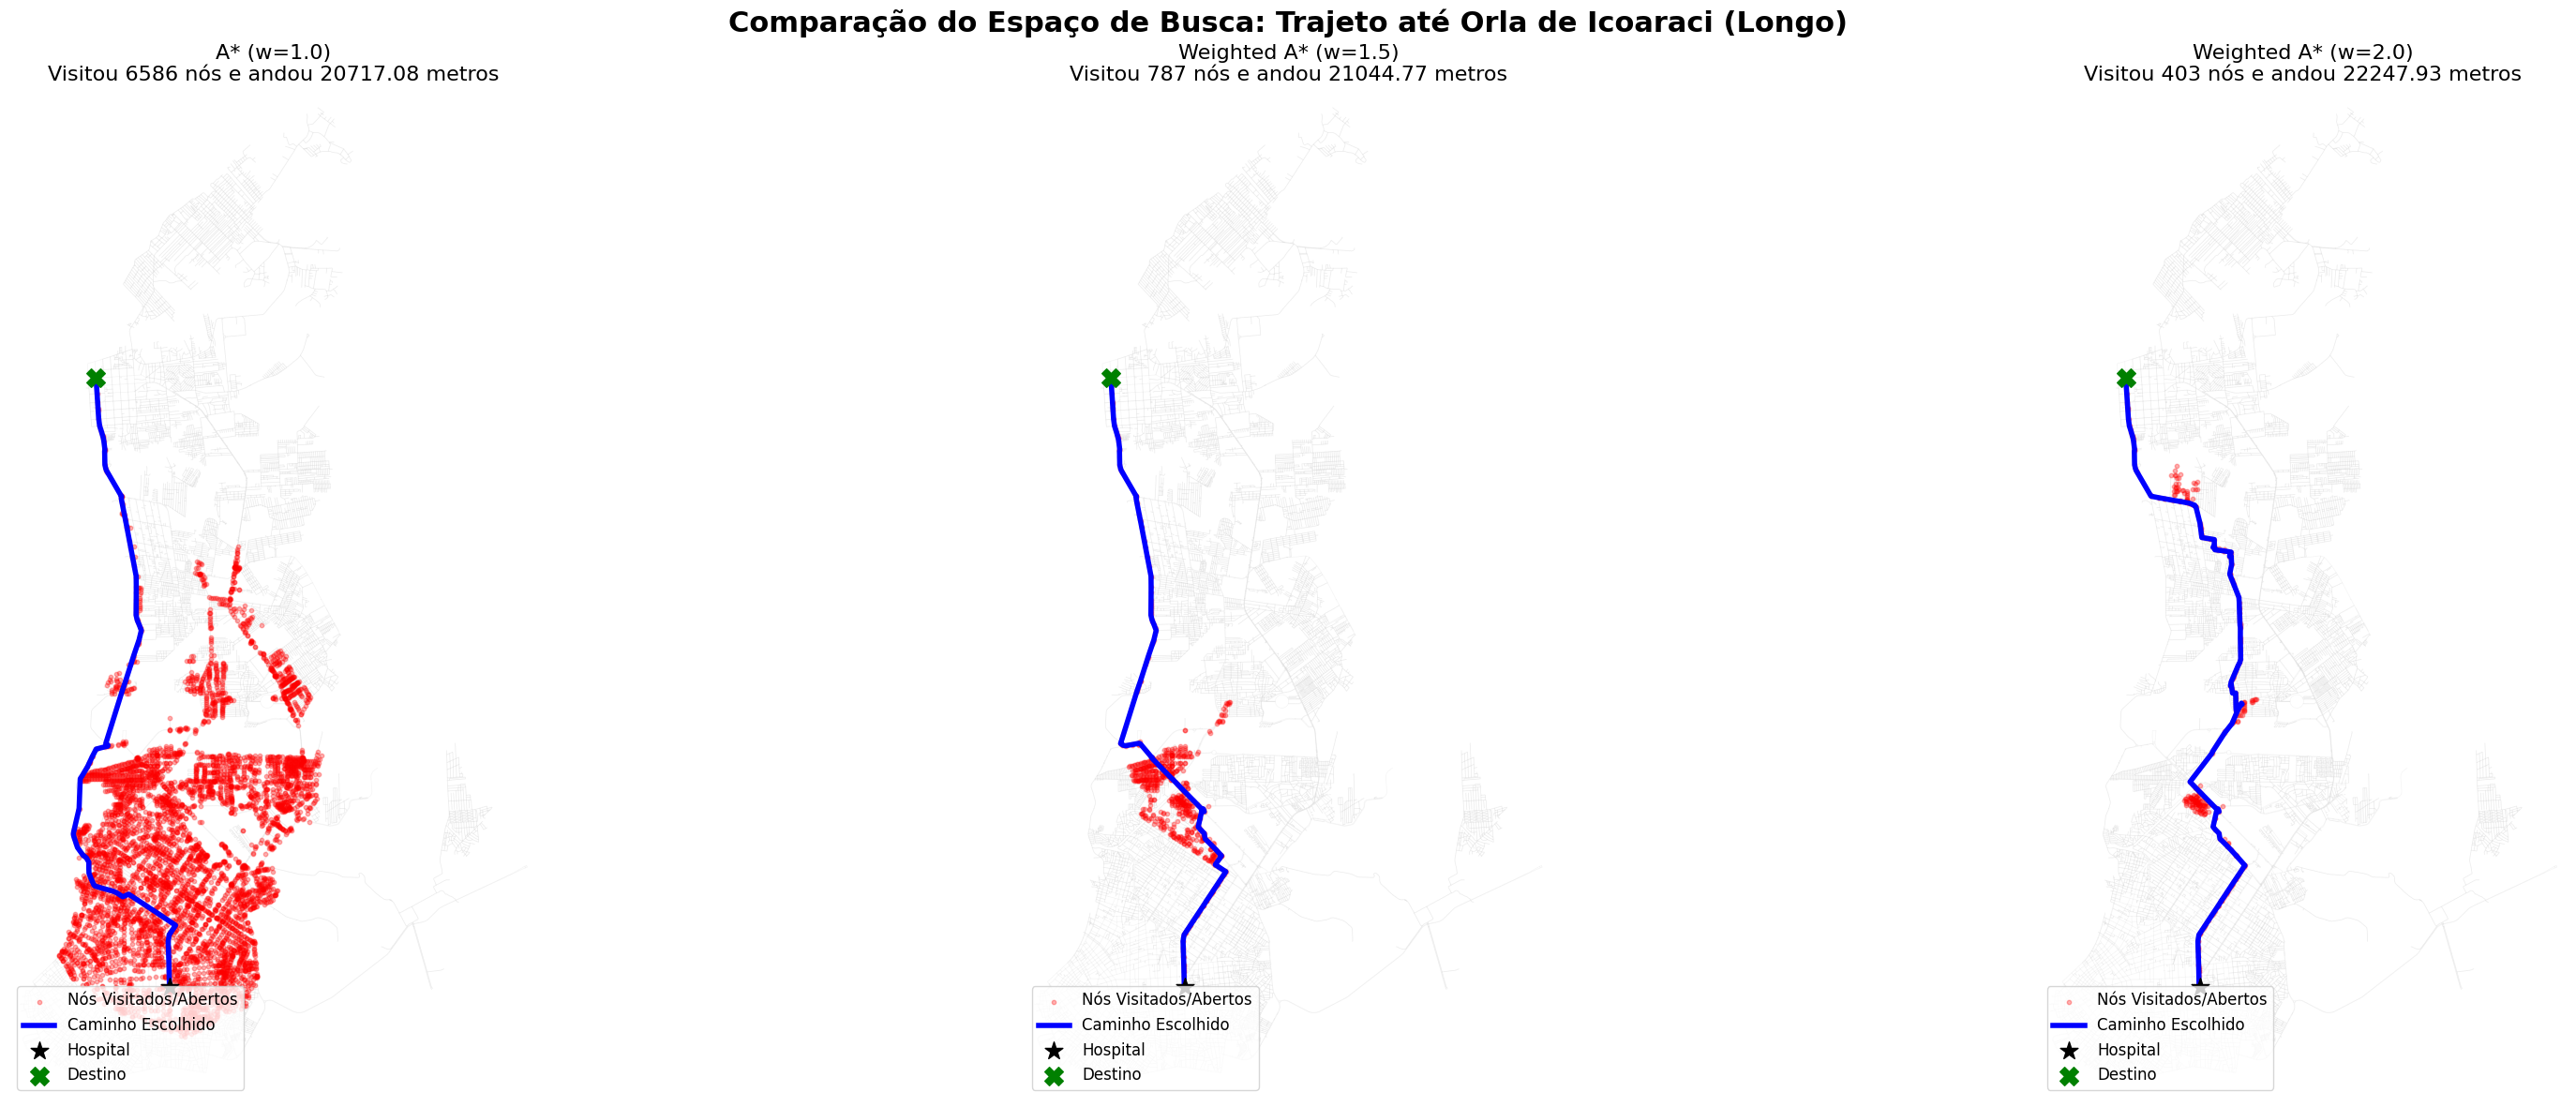

In [10]:
alvo = "Orla de Icoaraci (Longo)"
algoritmos_plot = [
    "A* (w=1.0)",            # ótimo e cauteloso
    "Weighted A* (w=1.5)",   # intermediário
    "Weighted A* (w=2.0)",   # mais ganancioso
]

fig, axes = plt.subplots(1, 3, figsize=(36, 12))
fig.suptitle(f"Comparação do Espaço de Busca: Trajeto até {alvo}", fontsize=22, fontweight='bold')

for ax, alg_name in zip(axes, algoritmos_plot):
    nos_exp = explored_dict[alvo][alg_name]
    rota = paths_dict[alvo][alg_name]

    ox.plot_graph(G, ax=ax, show=False, close=False, edge_color='#cccccc',
                  edge_linewidth=0.5, edge_alpha=0.2, node_size=0, bgcolor='white')

    # Mancha vermelha (nós abertos/visitados)
    x_exp = [G.nodes[n]['x'] for n in nos_exp]
    y_exp = [G.nodes[n]['y'] for n in nos_exp]
    ax.scatter(x_exp, y_exp, c='red', s=10, alpha=0.3, label='Nós Visitados/Abertos')

    # Rota final em azul
    if rota:
        x_route = [G.nodes[n]['x'] for n in rota]
        y_route = [G.nodes[n]['y'] for n in rota]
        ax.plot(x_route, y_route, c='blue', linewidth=4, label='Caminho Escolhido')

    # Origem e destino
    ax.scatter([loc_hospital[1]], [loc_hospital[0]], c='black', s=200, marker='*',
               label='Hospital', zorder=5)
    ax.scatter([G.nodes[destinations[alvo]]['x']], [G.nodes[destinations[alvo]]['y']],
               c='green', s=200, marker='X', label='Destino', zorder=5)

    # Custo direto da lista de resultados
    custo_rota = next(item['Custo (m)'] for item in results
                      if item['Algoritmo'] == alg_name and item['Destino'] == alvo)
    ax.set_title(f"{alg_name}\nVisitou {len(nos_exp)} nós e andou {custo_rota} metros", fontsize=16)
    ax.legend(fontsize=12, loc='lower left')

plt.tight_layout()
plt.show()

## 8. Estatísticas e Gráficos do Trade-Off

,Destino,Algoritmo,Custo (m),Nós Expandidos,Tempo (s)
0,UFPA (Curto),Gulosa,4085.31,59,0.00000
1,UFPA (Curto),A* (w=1.0),3410.81,396,0.00400
2,UFPA (Curto),Weighted A* (w=1.5),3621.58,77,0.00100
3,UFPA (Curto),Weighted A* (w=2.0),3513.40,45,0.00051
4,Aeroporto (Médio),Gulosa,19848.01,393,0.00201
5,Aeroporto (Médio),A* (w=1.0),11754.90,5103,0.05829
6,Aeroporto (Médio),Weighted A* (w=1.5),12009.90,1566,0.07464
7,Aeroporto (Médio),Weighted A* (w=2.0),12347.95,375,0.00952
8,Orla de Icoaraci (Longo),Gulosa,25124.81,442,0.00300
9,Orla de Icoaraci (Longo),A* (w=1.0),20717.08,6586,0.07654


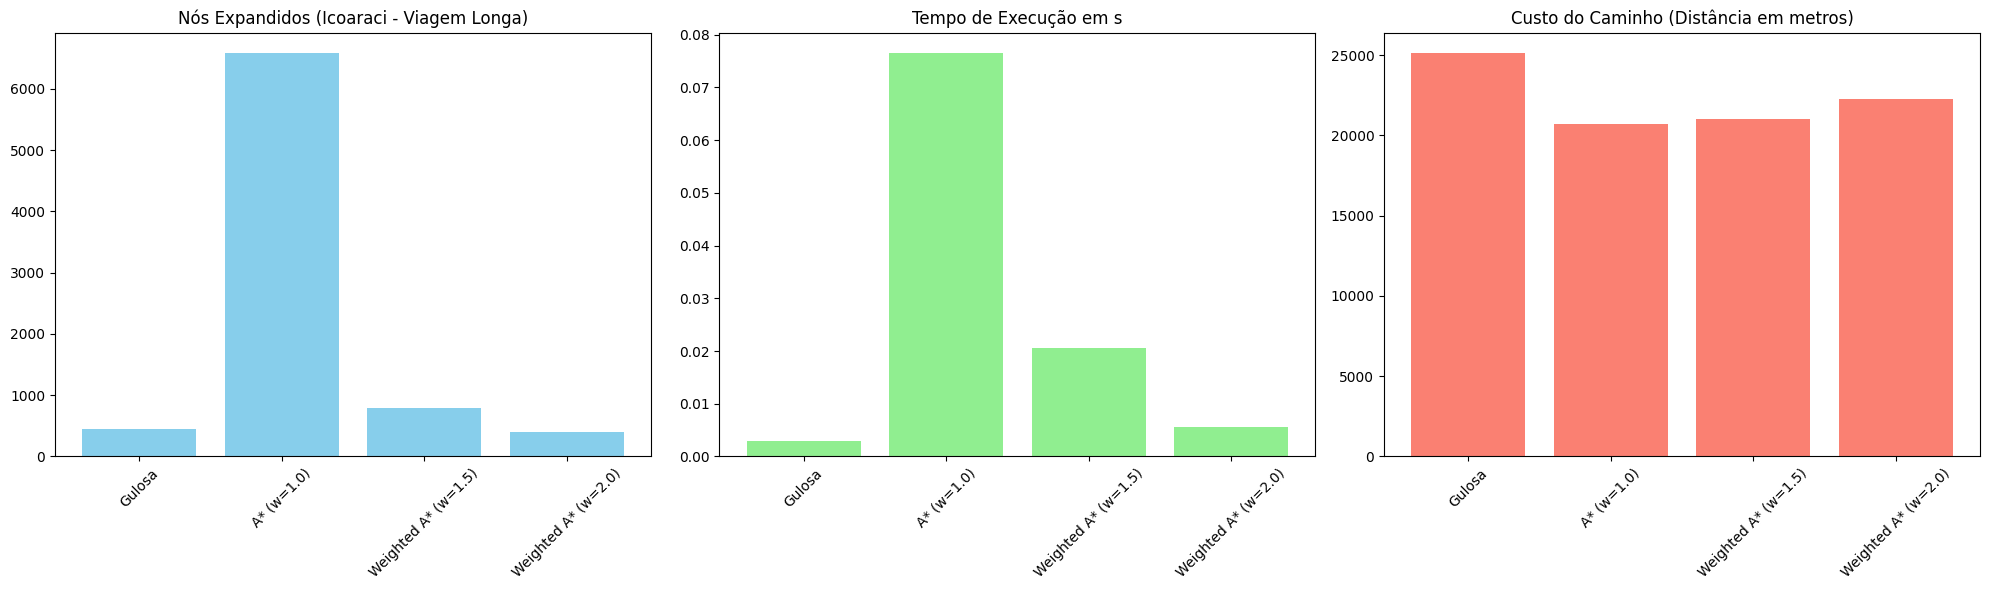

In [11]:
df_results = pd.DataFrame(results)
display(df_results)

# Gráficos comparativos usando matplotlib para o percurso longo
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
df_plot = df_results[df_results['Destino'] == 'Orla de Icoaraci (Longo)'] 

axes[0].bar(df_plot['Algoritmo'], df_plot['Nós Expandidos'], color='skyblue')
axes[0].set_title('Nós Expandidos (Icoaraci - Viagem Longa)')
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(df_plot['Algoritmo'], df_plot['Tempo (s)'], color='lightgreen')
axes[1].set_title('Tempo de Execução em s')
axes[1].tick_params(axis='x', rotation=45)

axes[2].bar(df_plot['Algoritmo'], df_plot['Custo (m)'], color='salmon')
axes[2].set_title('Custo do Caminho (Distância em metros)')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


## 9. Verificação de Qualidade (Optimalidade)
Aqui calculamos a diferença percentual do custo gerado por cada algoritmo em relação ao A* puro (que é garantidamente ótimo).

In [12]:
df_optimal = df_results[df_results['Algoritmo'] == 'A* (w=1.0)'][['Destino', 'Custo (m)']].rename(columns={'Custo (m)': 'Custo_Otimo'})
df_merged = df_results.merge(df_optimal, on='Destino')

df_merged['Erro (%)'] = ((df_merged['Custo (m)'] - df_merged['Custo_Otimo']) / df_merged['Custo_Otimo']) * 100
display(df_merged[['Destino', 'Algoritmo', 'Custo (m)', 'Custo_Otimo', 'Erro (%)']])


,Destino,Algoritmo,Custo (m),Custo_Otimo,Erro (%)
0,UFPA (Curto),Gulosa,4085.31,3410.81,19.775361
1,UFPA (Curto),A* (w=1.0),3410.81,3410.81,0.000000
2,UFPA (Curto),Weighted A* (w=1.5),3621.58,3410.81,6.179471
3,UFPA (Curto),Weighted A* (w=2.0),3513.40,3410.81,3.007790
4,UFPA (Curto),Bidirectional A*,3414.02,3410.81,0.094113
5,Aeroporto (Médio),Gulosa,19848.01,11754.90,68.848820
6,Aeroporto (Médio),A* (w=1.0),11754.90,11754.90,0.000000
7,Aeroporto (Médio),Weighted A* (w=1.5),12009.90,11754.90,2.169308
8,Aeroporto (Médio),Weighted A* (w=2.0),12347.95,11754.90,5.045130
9,Aeroporto (Médio),Bidirectional A*,11754.90,11754.90,0.000000


## 10. Discussão Crítica
**Análise da Optimalidade vs. Velocidade em Trechos Longos:**
O cenário mais revelador deste trabalho foi o despacho para Icoaraci. Ao analisarmos a visualização gráfica da Árvore de Busca (Seção 7), o *trade-off* estrutural dos algoritmos saltou aos olhos:
- O A* (w=1.0) precisou vasculhar dezenas de milhares de cruzamentos em quase todas as direções da cidade para poder afirmar, com certeza matemática, qual era o caminho mais curto. 
- Já o Weighted A*, com o viés da heurística ampliado, formou um estreito corredor de busca direcionado a Icoaraci. Ele não explorou bairros irrelevantes, atingindo o destino incrivelmente mais rápido, ao custo de entregar uma rota minimamente mais longa (erro quase insignificante perante o ganho de performance em tempo real de uma ambulância).

A Busca Gulosa tomou decisões apenas olhando para frente (para a meta), o que a fez ficar "presa" em curvas ou obstáculos viários, gerando rotas um pouco mais custosas, mas com um tempo de pensamento quase instantâneo.

**Limitações do Modelo e Dificuldades Enfrentadas:**
- **Tráfego Estático:** O grafo OSMnx considera apenas a geometria estática da rua. Para uma ambulância real na Av. Augusto Montenegro (que liga o centro a Icoaraci), 18 km no papel se transformam em um pesadelo no horário de pico. 
- **Mão Única e Retornos:** O modelo bidirecional sofre bastante com vias de mão única na prática, pois as árvores podem achar que se cruzam em vias largas, mas fisicamente a conversão do canteiro não existe.

**Possíveis Melhorias Futuras:**
- **Grafos Dependentes de Tempo:** Atualizar dinamicamente os pesos $g(n)$ integrando APIs do Waze para rotear o veículo por ruas menores caso as avenidas principais engarrafem.
- **Penalidades por Virada:** Modelar interseções com pesos adicionais caso a ambulância precise virar à esquerda cortando fluxo, favorecendo rotas com retas contínuas.